In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import  matplotlib.pyplot as plt

In [ ]:
conn=sqlite3.connect("../Dataset/inventory.db")

In [3]:
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)

In [4]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [5]:
for table in tables['name']:
    print("Table Name:",table)
    df=pd.read_sql_query(f"Select * from {table} limit 5",conn)
    display(df)

Table Name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table Name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table Name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table Name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table Name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [6]:
purchase_agg_df=pd.read_sql_query("""
select p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""",conn)

In [7]:
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [8]:
pd.read_sql("Select * from vendor_invoice limit 5",conn)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [9]:
pd.read_sql("""select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_Dollars,
vi.Freight,
(julianday(vi.InvoiceDate)-julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate)-julianday(vi.InvoiceDate)) as days_to_pay
from vendor_invoice vi
""",conn)

,PONumber,invoice_quantity,invoice_Dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [10]:
df=pd.read_sql("""with purchase_agg_df as(
select p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars)as total_item_dollars,
avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
)
select vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate)-julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate)-julianday(vi.InvoiceDate)) as days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay
from vendor_invoice vi
left join purchase_agg_df pa on vi.PONumber=pa.PONumber""",conn)

In [11]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [12]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             5543 non-null   int64  
 1   invoice_quantity     5543 non-null   int64  
 2   invoice_dollars      5543 non-null   float64
 3   Freight              5543 non-null   float64
 4   days_po_to_invoice   5543 non-null   float64
 5   days_to_pay          5543 non-null   float64
 6   total_brands         5543 non-null   int64  
 7   total_item_quantity  5543 non-null   int64  
 8   total_item_dollars   5543 non-null   float64
 9   avg_receiving_delay  5543 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 433.2 KB


In [14]:
def create_invoice_risk_label(row):
    if(abs(row["invoice_dollars"]-row["total_item_dollars"])>5):
        return 1

    if row['avg_receiving_delay']>10:
        return 1

    return 0

df["flag_invoice"]=df.apply(create_invoice_risk_label,axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

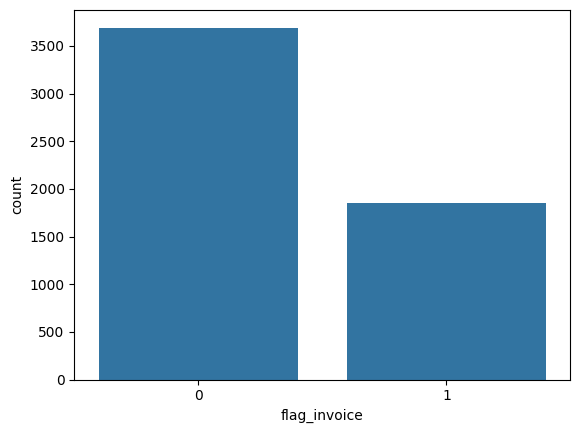

In [15]:
sns.countplot(x=df["flag_invoice"])
plt.show()

In [16]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


<Axes: >

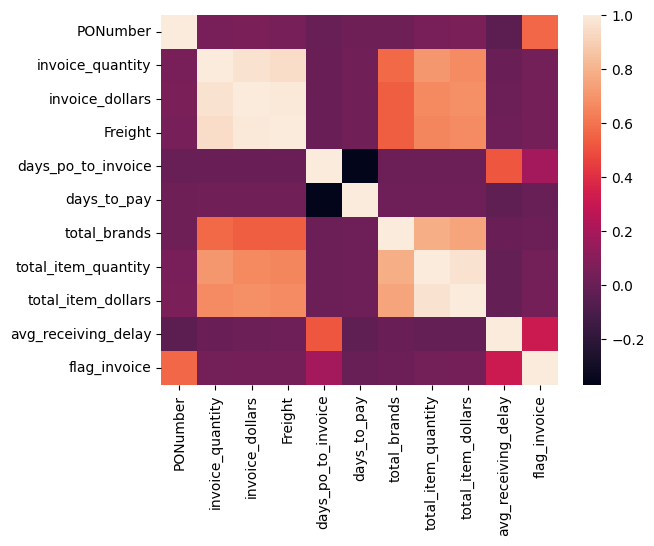

In [17]:
sns.heatmap(df.corr())

In [18]:
flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

In [19]:
significant_feature=[]
non_significant_feature=[]
result=[]

In [20]:
metrics=['invoice_quantity','invoice_dollars','Freight',
         'days_po_to_invoice','days_to_pay','total_brands',
         'total_item_quantity','total_item_dollars','avg_receiving_delay']

In [21]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean=flagged[metric].mean()
    normal_mean=normal[metric].mean()
    t_stat,p_value=ttest_ind(
         flagged[metric].dropna(),
         normal[metric].dropna(),
         equal_var=False
     )
    if p_value<0.05:
        significant_feature.append(metric)
        result.append({
            "metric":metric,
            "flagged_mean":flagged_mean.round(2),
            "normal_mean":normal_mean.round(2),
            "p_value":p_value.round(3)
        })

    else:
        non_significant_feature.append(metric)
        

In [22]:
non_significant_feature

['days_to_pay', 'total_brands']

In [23]:
significant_feature

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [24]:
pd.DataFrame(result)

,metric,flagged_mean,normal_mean,p_value
0,invoice_quantity,6728.28,5723.55,0.021
1,invoice_dollars,65600.61,54302.64,0.008
2,Freight,334.02,276.89,0.008
3,days_po_to_invoice,17.23,16.02,0.000
4,total_item_quantity,6728.28,5723.55,0.021
5,total_item_dollars,65600.61,54302.64,0.008
6,avg_receiving_delay,8.47,7.27,0.000


In [25]:
X=df[['invoice_quantity','invoice_dollars','Freight',
         'days_po_to_invoice','total_brands',
         'total_item_quantity','total_item_dollars']]
Y=df['flag_invoice']

In [41]:
Y.value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

In [42]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000,1
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333,1
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000,0
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130,1
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809,0


In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [28]:
lr=LogisticRegression()
dt=DecisionTreeClassifier(random_state=42)
rf=RandomForestClassifier(random_state=42)

In [29]:
lr.fit(x_train,y_train)
dt.fit(x_train,y_train)
rf.fit(x_train,y_train)

D:\Anaconda\envs\nlp\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score

In [31]:
def evaluate_model(model,x_test,y_test,model_name):
    pred=model.predict(x_test)
    precision=precision_score(y_test,pred)
    f1=f1_score(y_test,pred)
    recall=recall_score(y_test,pred)
    accuracy=accuracy_score(y_test,pred)*100

    print(f"\n{model_name} peraformance:")
    print(f"Precision: {precision:.2f}")
    print(f"F1_Score: {f1:.2f}")
    print(f"Recall: {recall:.2f}%")
    print(f"Accuracy: {accuracy:.2f}%")

In [32]:
evaluate_model(lr,x_test,y_test,"Logistic Regression")
evaluate_model(dt,x_test,y_test,"Decision Tree")
evaluate_model(rf,x_test,y_test,"Random Forest")


Logistic Regression peraformance:
Precision: 0.44
F1_Score: 0.04
Recall: 0.02%
Accuracy: 65.19%

Decision Tree peraformance:
Precision: 0.73
F1_Score: 0.72
Recall: 0.71%
Accuracy: 81.06%

Random Forest peraformance:
Precision: 0.93
F1_Score: 0.79
Recall: 0.68%
Accuracy: 87.20%


In [33]:
feature_importance=pd.DataFrame({
    "feature":x_train.columns,
    "importance":rf.feature_importances_
}).sort_values(by="importance",ascending=False)

In [34]:
feature_importance

,feature,importance
6,total_item_dollars,0.221633
5,total_item_quantity,0.174214
1,invoice_dollars,0.158418
2,Freight,0.150069
0,invoice_quantity,0.135212
4,total_brands,0.083123
3,days_po_to_invoice,0.077330


In [35]:
# Removing least important feature
X=df[['invoice_quantity','invoice_dollars','Freight',
         'total_item_quantity','total_item_dollars']]
Y=df['flag_invoice']

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [50]:
lr=LogisticRegression()
dt=DecisionTreeClassifier(random_state=42)
rf_1=RandomForestClassifier(random_state=42)

In [51]:
lr.fit(x_train,y_train)
dt.fit(x_train,y_train)
rf_1.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
evaluate_model(lr,x_test,y_test,"Logistic Regression")
evaluate_model(dt,x_test,y_test,"Decision Tree")
evaluate_model(rf_1,x_test,y_test,"Random Forest")


Logistic Regression peraformance:
Precision: 0.60
F1_Score: 0.02
Recall: 0.01%
Accuracy: 65.46%

Decision Tree peraformance:
Precision: 0.76
F1_Score: 0.76
Recall: 0.77%
Accuracy: 83.50%

Random Forest peraformance:
Precision: 0.94
F1_Score: 0.81
Recall: 0.72%
Accuracy: 88.46%


In [ ]:
rf=RandomForestClassifier(random_state=42)

In [41]:
param_prid={
    "n_estimators":[100,200,300],
    "max_depth":[None,3,5,7],
    "min_sample_split":[2,3,5],
    "min_sample_leaf":[1,2,5],
    "criterion":['gini','entropy']
}

In [42]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

In [43]:
rf=RandomForestClassifier(random_state=42,n_jobs=-1)

param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[None,3,5,7],
    "min_samples_split":[2,3,5],
    "min_samples_leaf":[1,2,5],
    "criterion":['gini','entropy']
}
score=make_scorer(f1_score)

grid_search=GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=score,
    cv=5,
    verbose=5,
    n_jobs=-1
)

In [44]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,scoring,make_scorer(f...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [45]:
evaluate_model(grid_search,x_test,y_test,"Grid Search")


Grid Search peraformance:
Precision: 0.96
F1_Score: 0.81
Recall: 0.71%
Accuracy: 88.82%


In [46]:
from sklearn.metrics import confusion_matrix

In [47]:
confusion_matrix(y_test,grid_search.predict(x_test))

array([[713,  12],
       [112, 272]], dtype=int64)

In [56]:
confusion_matrix(y_test,rf_1.predict(x_test))

array([[706,  19],
       [109, 275]], dtype=int64)